# Agent Evaluation — LLM-as-a-Judge Test Suite

Comprehensive evaluation of all four sub-agents and the full orchestrator.

Each agent is tested with representative user messages. Responses are scored automatically by **GPT-4o-mini acting as an LLM judge**, rating each response on:

| Dimension | Scale | Meaning |
|---|---|---|
| **Relevance** | 1–5 | Does the response address what was asked? |
| **Correctness** | 1–5 | Is the information factually/logically accurate? |
| **Helpfulness** | 1–5 | Does the response usefully assist the customer? |
| **Pass/Fail** | ✅ / ❌ | Meets the minimum quality bar (avg ≥ 3) |

Agents tested:
1. Intent Classifier (routing accuracy)
2. Menu Agent
3. FAQ Agent
4. Order Agent
5. Support Agent
6. Full Orchestrator (end-to-end)


In [19]:
"""Setup: find project root, add to sys.path, and load environment variables."""
import sys, os
from pathlib import Path

def _find_project_root(marker: str = "requirements.txt") -> Path:
    """Walk upward from cwd until a marker file is found."""
    current = Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root (searched for '{marker}' from {current})"
    )

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

import json, time, textwrap
from dataclasses import dataclass, field
from typing import Optional
from IPython.display import display, HTML
import pandas as pd

from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

print("✅ Project root:", PROJECT_ROOT)
print("✅ OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))


✅ Project root: d:\college\semester6\nlp\restaurant_agentic_customer_service
✅ OPENAI_API_KEY set: True


In [20]:
"""LLM-as-a-Judge: GPT-4o-mini evaluates every agent response."""

from pydantic import BaseModel, Field

class JudgeScore(BaseModel):
    relevance: int = Field(ge=1, le=5, description="Does the response address what the user asked? (1=completely off, 5=perfectly on-topic)")
    correctness: int = Field(ge=1, le=5, description="Is the information accurate and logically sound? (1=wrong/misleading, 5=fully correct)")
    helpfulness: int = Field(ge=1, le=5, description="Does the response genuinely help the user? (1=not helpful, 5=very helpful)")
    reasoning: str = Field(description="Brief explanation of the scores (2-4 sentences).")

_judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(JudgeScore)

JUDGE_SYSTEM = """You are an expert evaluator for a restaurant customer-service AI assistant.
Given a USER MESSAGE and the AGENT RESPONSE, rate the response on three dimensions (1–5 each):
- relevance  : Does the response address what the user asked?
- correctness: Is the information accurate and logically sound?
- helpfulness: Does the response genuinely help the user?

Be fair but critical. A generic or evasive answer should score 2–3 at most.
A clear, specific, accurate answer should score 4–5.
"""

def llm_judge(user_message: str, agent_response: str, criteria: str = "") -> JudgeScore:
    """Evaluate agent_response using GPT-4o-mini as a judge."""
    extra = f"\n\nEvaluation criteria hint: {criteria}" if criteria else ""
    prompt = (
        f"USER MESSAGE:\n{user_message}\n\n"
        f"AGENT RESPONSE:\n{agent_response}"
        f"{extra}"
    )
    return _judge_llm.invoke([
        {"role": "system", "content": JUDGE_SYSTEM},
        {"role": "user", "content": prompt},
    ])

print("✅ LLM judge ready.")


✅ LLM judge ready.


In [21]:
"""Shared helpers: state factory, test runner, pretty-print results."""

from typing import Any

# ── State factory ──────────────────────────────────────────────────────────────
def make_state(user_message: str, **overrides) -> dict:
    """Return a fully-initialised MainState dict."""
    base = {
        "user_message": user_message,
        "intent": None,
        "response": None,
        "session_id": None,
        "customer_id": None,
        "order_id": None,
        "extracted_order": None,
        "extracted_complaint": None,
        "tool_result": None,
        "next_step": None,
        "order_ready": None,
        "order_confirmed": None,
        "order_awaiting_confirmation": None,
        "missing_fields": None,
        "invalid_items": None,
        "requires_follow_up": None,
        "needs_human": None,
        "messages": [],
        "faq": None,
        "reflection_satisfied": None,
        "iteration_count": 0,
        "max_iterations": 3,
        "clarification_attempts": 0,
    }
    base.update(overrides)
    return base

# ── Test case dataclass ────────────────────────────────────────────────────────
@dataclass
class TestCase:
    id: str
    user_message: str
    criteria: str
    expected_intent: Optional[str] = None
    state_overrides: dict = field(default_factory=dict)

@dataclass
class TestResult:
    id: str
    user_message: str
    response: str
    intent: Optional[str]
    expected_intent: Optional[str]
    score: Optional[JudgeScore]
    avg_score: float
    passed: bool
    error: Optional[str] = None

# ── Runner ─────────────────────────────────────────────────────────────────────
def run_tests(test_cases: list[TestCase], agent_fn, agent_label: str) -> list[TestResult]:
    """
    For each test case:
      1. Build state → invoke agent_fn(state) → extract response
      2. Feed response to LLM judge
      3. Collect TestResult
    agent_fn must accept a state dict and return a state dict with a 'response' key.
    """
    results = []
    for tc in test_cases:
        print(f"  [{agent_label}] Running {tc.id} …", end=" ", flush=True)
        state = make_state(tc.user_message, **tc.state_overrides)
        response = ""
        intent = None
        score = None
        error = None
        try:
            out = agent_fn(state)
            response = out.get("response") or "(no response)"
            intent = out.get("intent")
        except Exception as exc:
            error = str(exc)
            response = f"ERROR: {error}"

        try:
            score = llm_judge(tc.user_message, response, tc.criteria)
            avg = round((score.relevance + score.correctness + score.helpfulness) / 3, 2)
        except Exception as je:
            avg = 0.0
            error = (error or "") + f" | judge error: {je}"

        passed = avg >= 3.0 and error is None
        results.append(TestResult(
            id=tc.id,
            user_message=tc.user_message,
            response=response,
            intent=intent,
            expected_intent=tc.expected_intent,
            score=score,
            avg_score=avg,
            passed=passed,
            error=error,
        ))
        status = "✅" if passed else "❌"
        print(f"{status} avg={avg}")
    return results

# ── Pretty display ─────────────────────────────────────────────────────────────
def show_results(results: list[TestResult], title: str = ""):
    if title:
        display(HTML(f"<h3>{'🔎 ' + title}</h3>"))

    rows = []
    for r in results:
        intent_ok = ""
        if r.expected_intent:
            intent_ok = "✅" if r.intent == r.expected_intent else f"❌ (got {r.intent})"

        rows.append({
            "ID": r.id,
            "Message": textwrap.shorten(r.user_message, 50),
            "Intent": f"{r.intent} {intent_ok}",
            "Rel": r.score.relevance if r.score else "—",
            "Cor": r.score.correctness if r.score else "—",
            "Hlp": r.score.helpfulness if r.score else "—",
            "Avg": r.avg_score,
            "Pass": "✅" if r.passed else "❌",
            "Response (truncated)": textwrap.shorten(r.response, 80),
        })

    df = pd.DataFrame(rows)
    display(df.to_html(index=False, escape=False), metadata={"text/html": True})

    # Print full reasoning for failed tests
    for r in results:
        if not r.passed:
            print(f"\n⚠️  {r.id} FAILED")
            if r.error:
                print(f"   Error  : {r.error}")
            if r.score:
                print(f"   Reasoning: {r.score.reasoning}")
            print(f"   Full response:\n   {r.response[:400]}")

# ── Global ledger ──────────────────────────────────────────────────────────────
ALL_RESULTS: list[TestResult] = []

print("✅ Helpers ready.")


✅ Helpers ready.


---
## 1. Intent Classifier

Tests that the orchestrator routes user messages to the correct sub-agent.

Scoring is based on intent accuracy (expected vs. actual) **plus** the LLM judge score on the final response.


In [22]:
"""Intent Classifier Tests — routing accuracy + response quality."""

from app.my_agent.agents.intent_classifier import build_orchestrator_graph

_orchestrator = build_orchestrator_graph()

def orchestrator_agent(state: dict) -> dict:
    return _orchestrator.invoke(state)

INTENT_TESTS = [
    TestCase("INT_001", "What items do you have on the menu?",
             "Should respond with menu information or a list of dishes.",
             expected_intent="menu"),
    TestCase("INT_002", "I'd like to order two burgers please.",
             "Should acknowledge the order intent and start the order process.",
             expected_intent="order"),
    TestCase("INT_003", "What time do you close tonight?",
             "Should provide operating hours or direct the customer appropriately.",
             expected_intent="faq"),
    TestCase("INT_004", "My pizza was cold and I want a refund.",
             "Should express empathy and initiate a support/complaint workflow.",
             expected_intent="support"),
    TestCase("INT_005", "Can you explain quantum entanglement?",
             "Should politely decline and redirect to restaurant-related topics.",
             expected_intent="off_topic"),
    TestCase("INT_006", "Do you deliver to downtown?",
             "Should answer the delivery area question (FAQ intent).",
             expected_intent="faq"),
    TestCase("INT_007", "I want to cancel my last order.",
             "Should handle the cancellation under the order or support intent.",
             expected_intent="order"),
    TestCase("INT_008", "How much does the pasta cost?",
             "Should provide the price of the pasta dish.",
             expected_intent="menu"),
]

intent_results = run_tests(INTENT_TESTS, orchestrator_agent, "IntentClassifier")
ALL_RESULTS.extend(intent_results)
show_results(intent_results, "Intent Classifier Results")


  [IntentClassifier] Running INT_001 … ✅ avg=5.0
  [IntentClassifier] Running INT_002 … ✅ avg=5.0
  [IntentClassifier] Running INT_003 … state at the end of graph {'user_message': 'What time do you close tonight?', 'intent': 'faq', 'response': 'We close tonight at 11:00 PM. Let me know if you have any other questions! 😊', 'session_id': None, 'customer_id': None, 'order_id': None, 'extracted_order': None, 'extracted_complaint': None, 'tool_result': {'score': np.float64(0.4802586388473589)}, 'next_step': None, 'order_ready': None, 'order_confirmed': None, 'order_awaiting_confirmation': None, 'missing_fields': None, 'invalid_items': None, 'requires_follow_up': None, 'needs_human': None, 'messages': [], 'faq': <app.models.faq.FAQ object at 0x00000134326C1C70>, 'reflection_satisfied': None, 'iteration_count': 0, 'max_iterations': 3, 'clarification_attempts': 0}
✅ avg=5.0
  [IntentClassifier] Running INT_004 … ✅ avg=5.0
  [IntentClassifier] Running INT_005 … ❌ avg=1.67
  [IntentClassifier] R

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>ID</th>\n      <th>Message</th>\n      <th>Intent</th>\n      <th>Rel</th>\n      <th>Cor</th>\n      <th>Hlp</th>\n      <th>Avg</th>\n      <th>Pass</th>\n      <th>Response (truncated)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>INT_001</td>\n      <td>What items do you have on the menu?</td>\n      <td>menu ✅</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>✅</td>\n      <td>Sure! Here’s a delightful selection of items from our menu: 1. **Classic [...]</td>\n    </tr>\n    <tr>\n      <td>INT_002</td>\n      <td>I\'d like to order two burgers please.</td>\n      <td>order ✅</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>✅</td>\n      <td>Your current order is 2x burger. Would you like that for **delivery** or [...]</td>\n    </tr>\n    <tr>\n      <td>INT_003</td>\n      <td>What time d


⚠️  INT_005 FAILED
   Reasoning: The response does not address the user's request for an explanation of quantum entanglement, which is completely unrelated to restaurant topics. It also incorrectly implies that the assistant cannot provide any information outside of restaurant-related topics, which is misleading. While it does attempt to redirect the conversation, it fails to provide any useful information or assistance regarding the user's inquiry.
   Full response:
   I'm here to help with everything related to our restaurant — menu, orders, delivery, and general questions. I'm not able to help with topics outside of that. Is there anything I can assist you with today? 🍽️

⚠️  INT_007 FAILED
   Reasoning: The agent's response does not address the user's request to cancel their last order at all. Instead, it prompts the user to place a new order, which is completely off-topic. This indicates a misunderstanding of the user's intent, leading to a response that is neither accurate nor h

---
## 2. Menu Agent

Tests that the menu agent correctly retrieves and presents menu information.


In [23]:
"""Menu Agent Tests — menu retrieval and recommendation quality."""

import uuid
from app.my_agent.agents.menu_agent import build_menu_graph
from langchain_core.messages import HumanMessage

def menu_agent(state: dict) -> dict:
    state["messages"] = [HumanMessage(content=state["user_message"])]
    graph = build_menu_graph(db=None)
    # MemorySaver checkpointer requires a thread_id in the config
    config = {"configurable": {"thread_id": str(uuid.uuid4())}}
    return graph.invoke(state, config=config)

MENU_TESTS = [
    TestCase("MENU_001", "What items are on the menu?",
             "Should list multiple menu items with names and prices."),
    TestCase("MENU_002", "How much does the burger cost?",
             "Should provide the price of the burger specifically."),
    TestCase("MENU_003", "Do you have any pasta dishes?",
             "Should confirm whether pasta is available and provide details."),
    TestCase("MENU_004", "I'm in the mood for something spicy. What do you recommend?",
             "Should recommend one or more spicy menu items with names and descriptions."),
    TestCase("MENU_005", "What's your most popular item?",
             "Should suggest a specific menu item as popular or highly-rated."),
    TestCase("MENU_006", "Give me something light and healthy.",
             "Should recommend a lighter or healthier menu option with name and price."),
    TestCase("MENU_007", "What vegetarian options do you have?",
             "Should list or describe vegetarian-friendly menu items."),
    TestCase("MENU_008", "Tell me about the pizza.",
             "Should describe the pizza item(s) available including price and description."),
]

menu_results = run_tests(MENU_TESTS, menu_agent, "MenuAgent")
ALL_RESULTS.extend(menu_results)
show_results(menu_results, "Menu Agent Results")


  [MenuAgent] Running MENU_001 … ✅ avg=5.0
  [MenuAgent] Running MENU_002 … ✅ avg=5.0
  [MenuAgent] Running MENU_003 … ✅ avg=5.0
  [MenuAgent] Running MENU_004 … ✅ avg=5.0
  [MenuAgent] Running MENU_005 … ✅ avg=3.33
  [MenuAgent] Running MENU_006 … ✅ avg=5.0
  [MenuAgent] Running MENU_007 … ✅ avg=5.0
  [MenuAgent] Running MENU_008 … ✅ avg=5.0


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>ID</th>\n      <th>Message</th>\n      <th>Intent</th>\n      <th>Rel</th>\n      <th>Cor</th>\n      <th>Hlp</th>\n      <th>Avg</th>\n      <th>Pass</th>\n      <th>Response (truncated)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>MENU_001</td>\n      <td>What items are on the menu?</td>\n      <td>None</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>✅</td>\n      <td>Here’s a delightful selection of items from our menu: 1. **Classic Beef [...]</td>\n    </tr>\n    <tr>\n      <td>MENU_002</td>\n      <td>How much does the burger cost?</td>\n      <td>None</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>✅</td>\n      <td>The Classic Beef Burger costs $75.00. It\'s a delicious grilled beef patty [...]</td>\n    </tr>\n    <tr>\n      <td>MENU_003</td>\n      <td>Do you have any pasta dishes

---
## 3. FAQ Agent

Tests that the FAQ agent retrieves accurate answers to common restaurant questions.


In [24]:
"""FAQ Agent Tests — accuracy and relevance of FAQ retrieval."""

from app.my_agent.agents.faq_agent import build_faq_graph

def faq_agent(state: dict) -> dict:
    graph = build_faq_graph(db=None)
    return graph.invoke(state)

FAQ_TESTS = [
    TestCase("FAQ_001", "What are your opening hours?",
             "Should state specific opening and closing times."),
    TestCase("FAQ_002", "Where is the restaurant located?",
             "Should provide an address or location description."),
    TestCase("FAQ_003", "Do you take reservations?",
             "Should clearly state whether reservations are accepted and how."),
    TestCase("FAQ_004", "Is there parking available?",
             "Should explain parking options near or at the restaurant."),
    TestCase("FAQ_005", "Do you offer delivery?",
             "Should state whether delivery is available and any relevant details."),
    TestCase("FAQ_006", "What is your refund policy?",
             "Should describe the refund or cancellation policy."),
    TestCase("FAQ_007", "Are you open on weekends?",
             "Should clarify weekend operating hours or status."),
    TestCase("FAQ_008", "Do you accommodate dietary restrictions?",
             "Should describe how the restaurant handles dietary needs or allergies."),
]

faq_results = run_tests(FAQ_TESTS, faq_agent, "FAQAgent")
ALL_RESULTS.extend(faq_results)
show_results(faq_results, "FAQ Agent Results")


  [FAQAgent] Running FAQ_001 … state at the end of graph {'user_message': 'What are your opening hours?', 'intent': None, 'response': 'Our restaurant is open daily from 10:00 AM to 11:00 PM, so you can visit us any day of the week, including weekends and holidays! 😊', 'session_id': None, 'customer_id': None, 'order_id': None, 'extracted_order': None, 'extracted_complaint': None, 'tool_result': {'score': np.float64(1.0)}, 'next_step': None, 'order_ready': None, 'order_confirmed': None, 'order_awaiting_confirmation': None, 'missing_fields': None, 'invalid_items': None, 'requires_follow_up': None, 'needs_human': None, 'messages': [], 'faq': <app.models.faq.FAQ object at 0x00000134726D90A0>, 'reflection_satisfied': None, 'iteration_count': 0, 'max_iterations': 3, 'clarification_attempts': 0}
✅ avg=5.0
  [FAQAgent] Running FAQ_002 … state at the end of graph {'user_message': 'Where is the restaurant located?', 'intent': None, 'response': "Sure! We're located at 14 Nile Corniche Street in Ca

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>ID</th>\n      <th>Message</th>\n      <th>Intent</th>\n      <th>Rel</th>\n      <th>Cor</th>\n      <th>Hlp</th>\n      <th>Avg</th>\n      <th>Pass</th>\n      <th>Response (truncated)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>FAQ_001</td>\n      <td>What are your opening hours?</td>\n      <td>None</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.0</td>\n      <td>✅</td>\n      <td>Our restaurant is open daily from 10:00 AM to 11:00 PM, so you can visit [...]</td>\n    </tr>\n    <tr>\n      <td>FAQ_002</td>\n      <td>Where is the restaurant located?</td>\n      <td>None</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.0</td>\n      <td>✅</td>\n      <td>Sure! We\'re located at 14 Nile Corniche Street in Cairo. You can also [...]</td>\n    </tr>\n    <tr>\n      <td>FAQ_003</td>\n      <td>Do you take reservations?</td>\n 

---
## 4. Order Agent

Tests order extraction, validation, and response across common ordering scenarios.


In [25]:
"""Order Agent Tests — order extraction, validation, confirmation flows."""

from app.my_agent.agents.order_agent import build_order_agent_graph

def order_agent(state: dict) -> dict:
    graph = build_order_agent_graph()
    return graph.invoke(state)

ORDER_TESTS = [
    TestCase("ORD_001",
             "I'd like to order 2 burgers and 1 pasta, please.",
             "Should acknowledge the order, list the items, and ask for confirmation or any missing info.",
             state_overrides={"customer_id": 1}),
    TestCase("ORD_002",
             "Order one pizza for delivery.",
             "Should capture the pizza item and ask for delivery address or customer details if missing.",
             state_overrides={"customer_id": 1}),
    TestCase("ORD_003",
             "What is the status of my order?",
             "Should ask for the order ID or state it cannot retrieve status without one.",
             state_overrides={"customer_id": 1}),
    TestCase("ORD_004",
             "I want to cancel my order.",
             "Should ask for the order ID and explain how to proceed with a cancellation.",
             state_overrides={"customer_id": 1}),
    TestCase("ORD_005",
             "Can I modify my order to add another burger?",
             "Should ask which order to modify or acknowledge the modification intent.",
             state_overrides={"customer_id": 1}),
    TestCase("ORD_006",
             "I'd like to order 1 burger, 1 pasta, and 1 pizza please.",
             "Should extract all three items and present an order summary asking for order type.",
             state_overrides={"customer_id": 1}),
    TestCase("ORD_007",
             "Give me a burger, hold the onions.",
             "Should capture the burger order and note the special instruction.",
             state_overrides={"customer_id": 1}),
    TestCase("ORD_008",
             "Order 3 pastas for dine-in.",
             "Should capture the pasta order with dine-in order type and confirm without asking for a delivery address.",
             state_overrides={"customer_id": 1}),
]

order_results = run_tests(ORDER_TESTS, order_agent, "OrderAgent")
ALL_RESULTS.extend(order_results)
show_results(order_results, "Order Agent Results")


  [OrderAgent] Running ORD_001 … ✅ avg=5.0
  [OrderAgent] Running ORD_002 … ✅ avg=5.0
  [OrderAgent] Running ORD_003 … ❌ avg=2.0
  [OrderAgent] Running ORD_004 … ❌ avg=1.0
  [OrderAgent] Running ORD_005 … ✅ avg=3.67
  [OrderAgent] Running ORD_006 … ✅ avg=5.0
  [OrderAgent] Running ORD_007 … ✅ avg=3.33
  [OrderAgent] Running ORD_008 … ❌ avg=2.33


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>ID</th>\n      <th>Message</th>\n      <th>Intent</th>\n      <th>Rel</th>\n      <th>Cor</th>\n      <th>Hlp</th>\n      <th>Avg</th>\n      <th>Pass</th>\n      <th>Response (truncated)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>ORD_001</td>\n      <td>I\'d like to order 2 burgers and 1 pasta, please.</td>\n      <td>None</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>✅</td>\n      <td>Your current order is 2x burger, 1x pasta. Would you like that for [...]</td>\n    </tr>\n    <tr>\n      <td>ORD_002</td>\n      <td>Order one pizza for delivery.</td>\n      <td>None</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>✅</td>\n      <td>Your current order is 1x pizza for delivery. Great choice! What\'s the [...]</td>\n    </tr>\n    <tr>\n      <td>ORD_003</td>\n      <td>What is the status 


⚠️  ORD_003 FAILED
   Reasoning: The response does not address the user's request for the status of their order, making it irrelevant. It also fails to provide accurate information, as it does not acknowledge the need for an order ID to check the status. Overall, the response is not helpful as it does not assist the user in finding the information they need.
   Full response:
   What would you like to order? Feel free to tell me the items and quantities! 😊

⚠️  ORD_004 FAILED
   Reasoning: The agent's response does not address the user's request to cancel their order at all; instead, it asks for new order details, which is completely off-topic. The information provided is not accurate or relevant to the user's needs, and it fails to assist the user in any meaningful way regarding their cancellation request.
   Full response:
   What would you like to order? Feel free to tell me the items and quantities! 😊

⚠️  ORD_008 FAILED
   Reasoning: The response does not address the user's reque

---
## 5. Support Agent

Tests empathy, complaint extraction, ticket creation, and escalation workflows.


In [26]:
"""Support Agent Tests — complaint handling, empathy, escalation."""

from app.my_agent.agents.support_agent import build_support_agent_graph

def support_agent(state: dict) -> dict:
    graph = build_support_agent_graph()
    return graph.invoke(state)

SUPPORT_TESTS = [
    TestCase("SUP_001",
             "My food was cold when it arrived. I'm very disappointed.",
             "Should apologise sincerely and initiate a complaint/ticket process.",
             state_overrides={"customer_id": 1}),
    TestCase("SUP_002",
             "I received the wrong order entirely. I ordered pasta but got a burger.",
             "Should acknowledge the wrong order, apologise, and offer a resolution (refund/replacement).",
             state_overrides={"customer_id": 1}),
    TestCase("SUP_003",
             "I want a full refund for order #42.",
             "Should acknowledge the refund request, capture the order ID, and explain next steps.",
             state_overrides={"customer_id": 1, "order_id": 42}),
    TestCase("SUP_004",
             "My delivery took over 2 hours. This is unacceptable!",
             "Should empathise with the delay, apologise, and describe how the complaint will be handled.",
             state_overrides={"customer_id": 1}),
    TestCase("SUP_005",
             "There was a hair in my pizza. I am disgusted.",
             "Should express genuine apology, log the hygiene complaint, and offer next steps.",
             state_overrides={"customer_id": 1}),
    TestCase("SUP_006",
             "What is the status of my support ticket #5?",
             "Should attempt to retrieve ticket #5 status or explain how to check it.",
             state_overrides={"customer_id": 1}),
    TestCase("SUP_007",
             "I was charged twice for the same order.",
             "Should acknowledge the billing error, apologise, and describe the resolution process.",
             state_overrides={"customer_id": 1}),
    TestCase("SUP_008",
             "The delivery driver was rude to me.",
             "Should express empathy, take the complaint seriously, and note it will be escalated.",
             state_overrides={"customer_id": 1}),
]

support_results = run_tests(SUPPORT_TESTS, support_agent, "SupportAgent")
ALL_RESULTS.extend(support_results)
show_results(support_results, "Support Agent Results")


  [SupportAgent] Running SUP_001 … ✅ avg=5.0
  [SupportAgent] Running SUP_002 … ✅ avg=5.0
  [SupportAgent] Running SUP_003 … ❌ avg=2.33
  [SupportAgent] Running SUP_004 … ✅ avg=5.0
  [SupportAgent] Running SUP_005 … ✅ avg=5.0
  [SupportAgent] Running SUP_006 … ❌ avg=2.67
  [SupportAgent] Running SUP_007 … ✅ avg=5.0
  [SupportAgent] Running SUP_008 … ✅ avg=5.0


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>ID</th>\n      <th>Message</th>\n      <th>Intent</th>\n      <th>Rel</th>\n      <th>Cor</th>\n      <th>Hlp</th>\n      <th>Avg</th>\n      <th>Pass</th>\n      <th>Response (truncated)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>SUP_001</td>\n      <td>My food was cold when it arrived. I\'m very [...]</td>\n      <td>None</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>✅</td>\n      <td>Dear [Customer\'s Name], I’m truly sorry to hear that your food arrived [...]</td>\n    </tr>\n    <tr>\n      <td>SUP_002</td>\n      <td>I received the wrong order entirely. I [...]</td>\n      <td>None</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>✅</td>\n      <td>Dear Customer, I’m truly sorry to hear that you received a burger instead [...]</td>\n    </tr>\n    <tr>\n      <td>SUP_003</td>\n      


⚠️  SUP_003 FAILED
   Reasoning: The response does not directly address the user's request for a refund, which is the main concern. While it mentions that the order is not linked to the user's account, it fails to provide any guidance on how the user can proceed with their refund request or rectify the issue. This makes the response less helpful and relevant.
   Full response:
   That order is not linked to your account, so I can't share details for that complaint.

⚠️  SUP_006 FAILED
   Reasoning: The response is somewhat relevant as it acknowledges the user's request for the status of a support ticket. However, it fails to provide any information about ticket #5 or how to check its status, which would have been more helpful. The correctness is moderate since it does not provide accurate information about the ticket's status, and the overall helpfulness is low as it does not assist the user in resolving their inquiry.
   Full response:
   I couldn't find that support ticket. Please c

---
## 6. Full Orchestrator — End-to-End Tests

Tests the complete pipeline from raw user message → intent classification → sub-agent → response. These mirror real customer interactions.


In [27]:
"""Full Orchestrator Tests — end-to-end routing and response quality."""

# Re-use the same orchestrator built for intent tests
E2E_TESTS = [
    # Menu path
    TestCase("E2E_001",
             "Show me what you have available to eat.",
             "Should list available menu items with names and prices.",
             expected_intent="menu",
             state_overrides={"customer_id": 1}),

    # Order path — simple order
    TestCase("E2E_002",
             "I want to place an order: 1 burger and a pasta.",
             "Should acknowledge the order with item details and next steps.",
             expected_intent="order",
             state_overrides={"customer_id": 1}),

    # FAQ path — hours
    TestCase("E2E_003",
             "Are you open right now? What are your hours?",
             "Should provide operating hours clearly.",
             expected_intent="faq",
             state_overrides={"customer_id": 1}),

    # Support path — complaint
    TestCase("E2E_004",
             "I'm really unhappy — the food I got was completely wrong.",
             "Should express empathy and begin the complaint process.",
             expected_intent="support",
             state_overrides={"customer_id": 1}),

    # Off-topic
    TestCase("E2E_005",
             "What's the weather like in Paris today?",
             "Should politely decline and redirect the user to restaurant topics.",
             expected_intent="off_topic",
             state_overrides={}),

    # Ambiguous / follow-up context
    TestCase("E2E_006",
             "Actually, make that 3 burgers instead.",
             "Should handle the quantity modification gracefully even without prior context.",
             expected_intent="order",
             state_overrides={"customer_id": 1}),

    # FAQ — policy
    TestCase("E2E_007",
             "Can I book a table for tonight?",
             "Should explain the reservation policy.",
             expected_intent="faq",
             state_overrides={}),

    # Support — refund
    TestCase("E2E_008",
             "I need a refund. The pizza arrived 3 hours late and was ice cold.",
             "Should acknowledge the dual complaint (lateness + temperature), apologise, and start a refund/complaint ticket.",
             expected_intent="support",
             state_overrides={"customer_id": 1}),

    # Gratitude handling
    TestCase("E2E_009",
             "Thanks for your help, that's all I needed!",
             "Should respond warmly and close the conversation politely.",
             state_overrides={}),

    # Menu — price check
    TestCase("E2E_010",
             "How much does the most expensive item on the menu cost?",
             "Should identify and state the most expensive item and its price.",
             expected_intent="menu",
             state_overrides={}),
]

e2e_results = run_tests(E2E_TESTS, orchestrator_agent, "Orchestrator-E2E")
ALL_RESULTS.extend(e2e_results)
show_results(e2e_results, "Full Orchestrator End-to-End Results")


  [Orchestrator-E2E] Running E2E_001 … ✅ avg=5.0
  [Orchestrator-E2E] Running E2E_002 … ✅ avg=5.0
  [Orchestrator-E2E] Running E2E_003 … state at the end of graph {'user_message': 'Are you open right now? What are your hours?', 'intent': 'faq', 'response': "Yes, we're open right now! Our hours are from 10:00 AM to 11:00 PM every day, including weekends and public holidays. How can I assist you today? 😊", 'session_id': None, 'customer_id': 1, 'order_id': None, 'extracted_order': None, 'extracted_complaint': None, 'tool_result': {'score': np.float64(0.7838524848056441)}, 'next_step': None, 'order_ready': None, 'order_confirmed': None, 'order_awaiting_confirmation': None, 'missing_fields': None, 'invalid_items': None, 'requires_follow_up': None, 'needs_human': None, 'messages': [], 'faq': <app.models.faq.FAQ object at 0x00000134326C1E80>, 'reflection_satisfied': None, 'iteration_count': 0, 'max_iterations': 3, 'clarification_attempts': 0}
✅ avg=5.0
  [Orchestrator-E2E] Running E2E_004 … ✅

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>ID</th>\n      <th>Message</th>\n      <th>Intent</th>\n      <th>Rel</th>\n      <th>Cor</th>\n      <th>Hlp</th>\n      <th>Avg</th>\n      <th>Pass</th>\n      <th>Response (truncated)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>E2E_001</td>\n      <td>Show me what you have available to eat.</td>\n      <td>menu ✅</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.0</td>\n      <td>✅</td>\n      <td>Sure! Here’s what we have available to eat: 1. **Classic Beef Burger** - [...]</td>\n    </tr>\n    <tr>\n      <td>E2E_002</td>\n      <td>I want to place an order: 1 burger and a pasta.</td>\n      <td>order ✅</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5</td>\n      <td>5.0</td>\n      <td>✅</td>\n      <td>Your current order is 1x burger, 1x pasta. Would you like that for [...]</td>\n    </tr>\n    <tr>\n      <td>E2E_003</td>\n      <td>Are yo

---
## 7. Score Summary

Aggregate scores across all agents, ranked by pass rate and average score.


In [28]:
"""Score Summary — aggregate all results into per-agent and overall reports."""

import pandas as pd
from IPython.display import display, HTML

# ── Group results by agent prefix ─────────────────────────────────────────────
def _group(prefix: str) -> list[TestResult]:
    return [r for r in ALL_RESULTS if r.id.startswith(prefix)]

AGENT_GROUPS = {
    "Intent Classifier": _group("INT_"),
    "Menu Agent":        _group("MENU_"),
    "FAQ Agent":         _group("FAQ_"),
    "Order Agent":       _group("ORD_"),
    "Support Agent":     _group("SUP_"),
    "Orchestrator E2E":  _group("E2E_"),
}

# ── Intent accuracy helper ─────────────────────────────────────────────────────
def _intent_accuracy(results: list[TestResult]) -> str:
    with_expected = [r for r in results if r.expected_intent]
    if not with_expected:
        return "N/A"
    correct = sum(1 for r in with_expected if r.intent == r.expected_intent)
    return f"{correct}/{len(with_expected)} ({100*correct//len(with_expected)}%)"

# ── Per-agent summary table ────────────────────────────────────────────────────
summary_rows = []
for agent, results in AGENT_GROUPS.items():
    if not results:
        continue
    scores_with_data = [r for r in results if r.score]
    rel = round(sum(r.score.relevance   for r in scores_with_data) / max(len(scores_with_data), 1), 2)
    cor = round(sum(r.score.correctness for r in scores_with_data) / max(len(scores_with_data), 1), 2)
    hlp = round(sum(r.score.helpfulness for r in scores_with_data) / max(len(scores_with_data), 1), 2)
    avg = round((rel + cor + hlp) / 3, 2)
    passed = sum(r.passed for r in results)
    summary_rows.append({
        "Agent":            agent,
        "Tests":            len(results),
        "Passed":           f"{passed}/{len(results)}",
        "Pass Rate":        f"{100*passed//len(results)}%",
        "Avg Relevance":    rel,
        "Avg Correctness":  cor,
        "Avg Helpfulness":  hlp,
        "Overall Avg":      avg,
        "Intent Accuracy":  _intent_accuracy(results),
    })

df_summary = pd.DataFrame(summary_rows)
display(HTML("<h3>📊 Agent Score Summary</h3>"))
display(df_summary.to_html(index=False, escape=False), metadata={"text/html": True})

# ── Overall totals ─────────────────────────────────────────────────────────────
total   = len(ALL_RESULTS)
passed  = sum(r.passed for r in ALL_RESULTS)
scored  = [r for r in ALL_RESULTS if r.score]
overall = round(sum((r.score.relevance + r.score.correctness + r.score.helpfulness) / 3
                    for r in scored) / max(len(scored), 1), 2)

print(f"\n{'='*55}")
print(f"  OVERALL  |  Tests: {total}  |  Passed: {passed}/{total}  |  Avg Score: {overall}/5")
print(f"{'='*55}")

# ── Failures detail ────────────────────────────────────────────────────────────
failures = [r for r in ALL_RESULTS if not r.passed]
if failures:
    display(HTML(f"<h3>❌ Failed Tests ({len(failures)})</h3>"))
    for r in failures:
        print(f"\n  [{r.id}] {r.user_message}")
        if r.error:
            print(f"    Error    : {r.error}")
        if r.score:
            print(f"    Scores   : Rel={r.score.relevance} Cor={r.score.correctness} Hlp={r.score.helpfulness} Avg={r.avg_score}")
            print(f"    Reasoning: {r.score.reasoning}")
        print(f"    Response : {r.response[:300]}")
else:
    print("\n🎉 All tests passed!")


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Agent</th>\n      <th>Tests</th>\n      <th>Passed</th>\n      <th>Pass Rate</th>\n      <th>Avg Relevance</th>\n      <th>Avg Correctness</th>\n      <th>Avg Helpfulness</th>\n      <th>Overall Avg</th>\n      <th>Intent Accuracy</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Intent Classifier</td>\n      <td>8</td>\n      <td>6/8</td>\n      <td>75%</td>\n      <td>4.12</td>\n      <td>4.00</td>\n      <td>4.12</td>\n      <td>4.08</td>\n      <td>8/8 (100%)</td>\n    </tr>\n    <tr>\n      <td>Menu Agent</td>\n      <td>8</td>\n      <td>8/8</td>\n      <td>100%</td>\n      <td>4.75</td>\n      <td>4.88</td>\n      <td>4.75</td>\n      <td>4.79</td>\n      <td>N/A</td>\n    </tr>\n    <tr>\n      <td>FAQ Agent</td>\n      <td>8</td>\n      <td>8/8</td>\n      <td>100%</td>\n      <td>4.88</td>\n      <td>4.88</td>\n      <td>4.88</td>\n      <td>4.88</td>\n      <td>N/A</td>


  OVERALL  |  Tests: 50  |  Passed: 43/50  |  Avg Score: 4.41/5



  [INT_005] Can you explain quantum entanglement?
    Scores   : Rel=2 Cor=1 Hlp=2 Avg=1.67
    Reasoning: The response does not address the user's request for an explanation of quantum entanglement, which is completely unrelated to restaurant topics. It also incorrectly implies that the assistant cannot provide any information outside of restaurant-related topics, which is misleading. While it does attempt to redirect the conversation, it fails to provide any useful information or assistance regarding the user's inquiry.
    Response : I'm here to help with everything related to our restaurant — menu, orders, delivery, and general questions. I'm not able to help with topics outside of that. Is there anything I can assist you with today? 🍽️

  [INT_007] I want to cancel my last order.
    Scores   : Rel=1 Cor=1 Hlp=1 Avg=1.0
    Reasoning: The agent's response does not address the user's request to cancel their last order at all. Instead, it prompts the user to place a new order, whic

---
## 8. Visualisations

Charts for the evaluation report — per-agent scores, pass rates, score distributions, and a heatmap of individual test results.

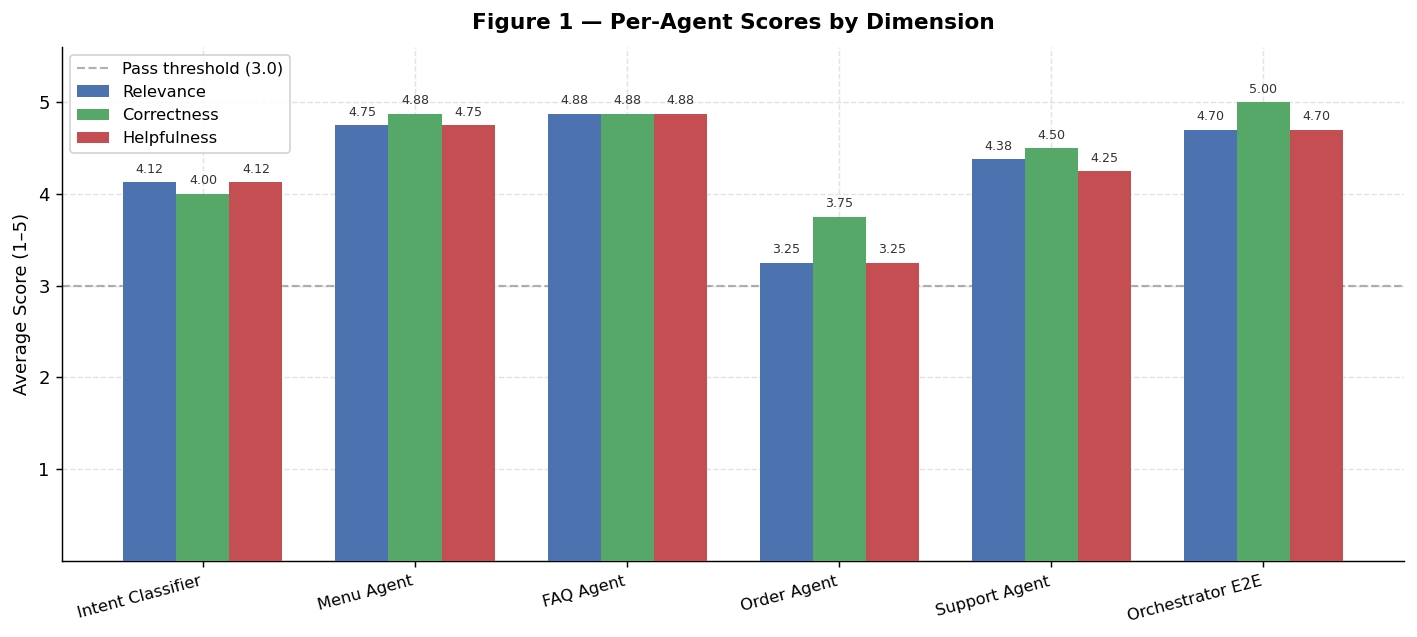

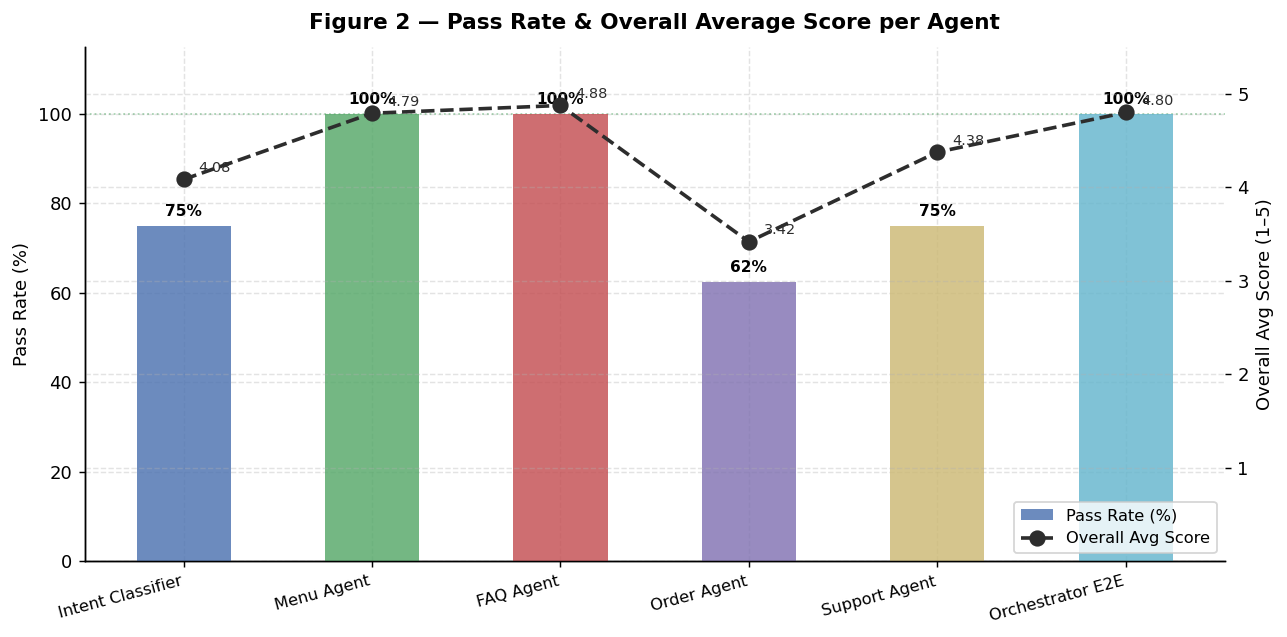

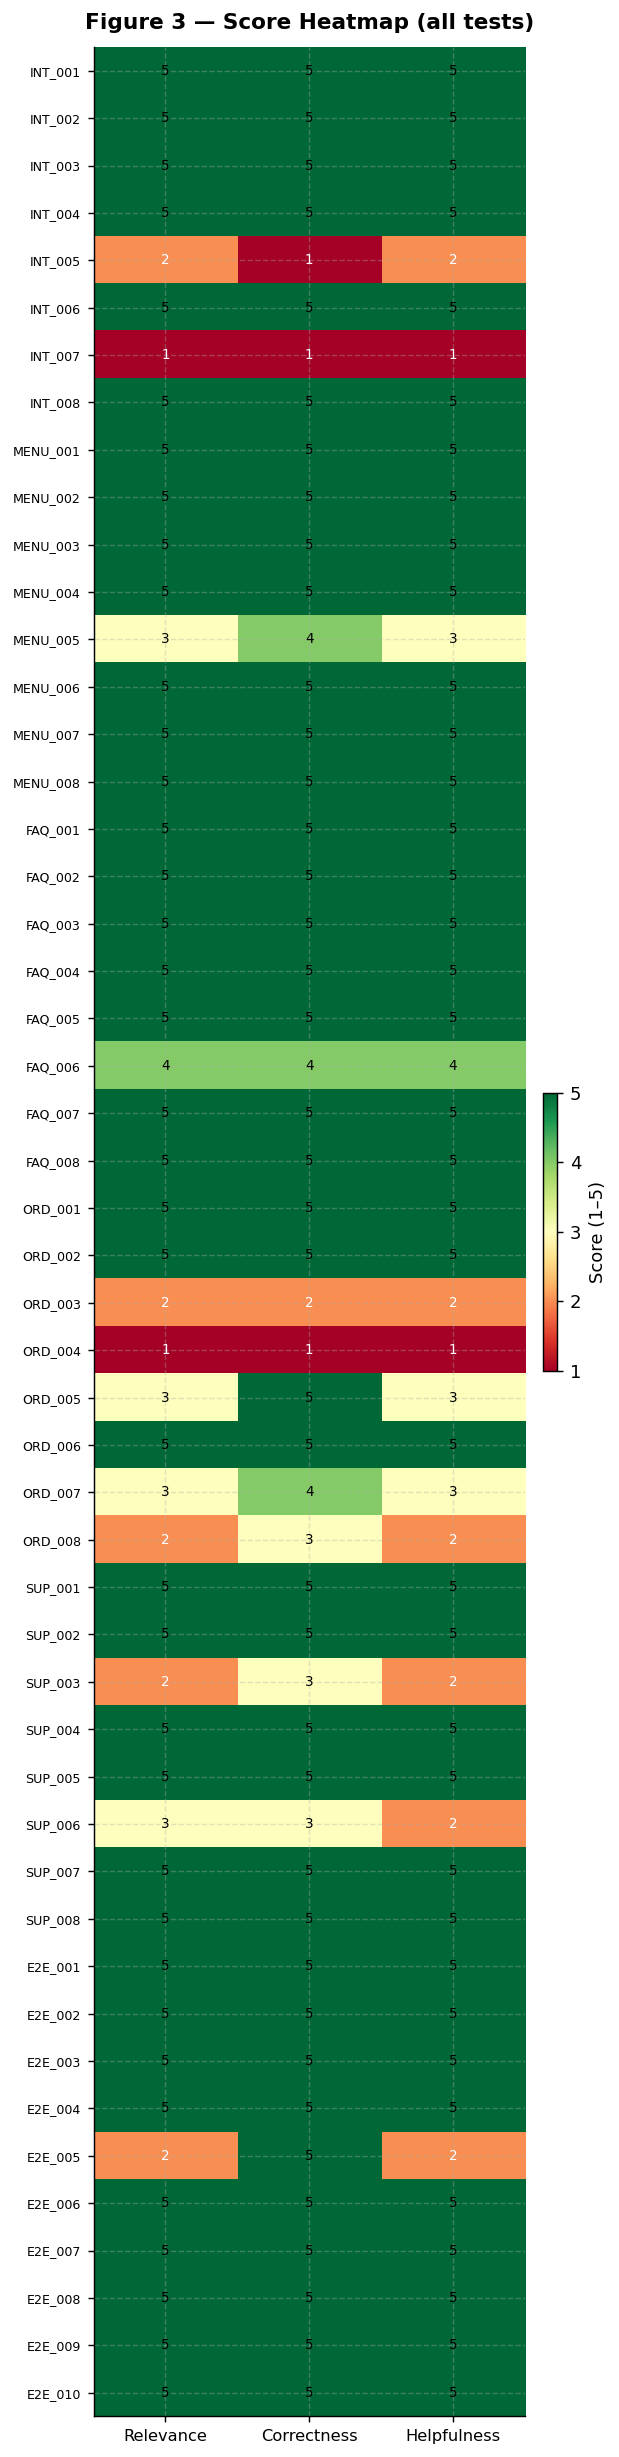

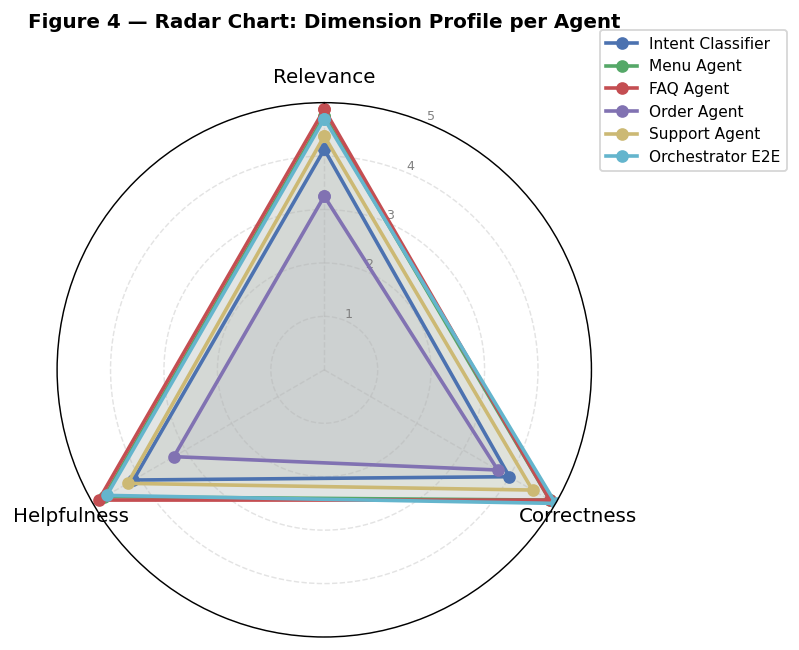


✅ All figures saved as PNG files alongside the notebook.


In [29]:
"""Visualisations — report-ready charts from ALL_RESULTS."""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
})

AGENT_ORDER = ["Intent Classifier", "Menu Agent", "FAQ Agent",
               "Order Agent", "Support Agent", "Orchestrator E2E"]
PREFIX_MAP  = {
    "Intent Classifier": "INT_",
    "Menu Agent":        "MENU_",
    "FAQ Agent":         "FAQ_",
    "Order Agent":       "ORD_",
    "Support Agent":     "SUP_",
    "Orchestrator E2E":  "E2E_",
}
COLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]

def _group(prefix):
    return [r for r in ALL_RESULTS if r.id.startswith(prefix)]

# ── Build per-agent aggregate data ────────────────────────────────────────────
agg = {}
for agent in AGENT_ORDER:
    results = _group(PREFIX_MAP[agent])
    scored  = [r for r in results if r.score]
    if not scored:
        continue
    rel = np.mean([r.score.relevance    for r in scored])
    cor = np.mean([r.score.correctness  for r in scored])
    hlp = np.mean([r.score.helpfulness  for r in scored])
    passed = sum(r.passed for r in results)
    agg[agent] = dict(rel=rel, cor=cor, hlp=hlp,
                      avg=(rel+cor+hlp)/3,
                      pass_rate=passed/len(results)*100,
                      n=len(results), n_pass=passed)

agents = list(agg.keys())
x      = np.arange(len(agents))
colors = COLORS[:len(agents)]

# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Grouped bar: Relevance / Correctness / Helpfulness per agent
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 5))
w = 0.25
bars_rel = ax.bar(x - w, [agg[a]["rel"] for a in agents], w, label="Relevance",    color="#4C72B0", zorder=3)
bars_cor = ax.bar(x,     [agg[a]["cor"] for a in agents], w, label="Correctness",  color="#55A868", zorder=3)
bars_hlp = ax.bar(x + w, [agg[a]["hlp"] for a in agents], w, label="Helpfulness",  color="#C44E52", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(agents, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0, 5.6)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_ylabel("Average Score (1–5)", fontsize=10)
ax.set_title("Figure 1 — Per-Agent Scores by Dimension", fontsize=12, fontweight="bold", pad=10)
ax.axhline(3, color="gray", linewidth=1.2, linestyle="--", alpha=0.6, label="Pass threshold (3.0)")
ax.legend(fontsize=9)

for bar in [*bars_rel, *bars_cor, *bars_hlp]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.07, f"{h:.2f}",
            ha="center", va="bottom", fontsize=7, color="#333")

plt.tight_layout()
plt.savefig("fig1_dimension_scores.png", bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Pass rate + overall avg score (dual axis)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax2.spines["top"].set_visible(False)   # keep twin-axis spine clean

pass_rates = [agg[a]["pass_rate"] for a in agents]
avg_scores = [agg[a]["avg"]       for a in agents]

bars = ax1.bar(x, pass_rates, 0.5, color=colors, alpha=0.82, zorder=3, label="Pass Rate (%)")
line = ax2.plot(x, avg_scores, "o--", color="#2d2d2d", linewidth=2,
                markersize=8, zorder=4, label="Overall Avg Score")

ax1.set_xticks(x)
ax1.set_xticklabels(agents, rotation=15, ha="right", fontsize=9)
ax1.set_ylim(0, 115)
ax1.set_ylabel("Pass Rate (%)", fontsize=10)
ax1.axhline(100, color="#55A868", linewidth=1, linestyle=":", alpha=0.5)
ax2.set_ylim(0, 5.5)
ax2.set_ylabel("Overall Avg Score (1–5)", fontsize=10)
ax2.set_yticks([1, 2, 3, 4, 5])

for bar, rate in zip(bars, pass_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{rate:.0f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
for xi, score in zip(x, avg_scores):
    ax2.text(xi + 0.08, score + 0.08, f"{score:.2f}", fontsize=8, color="#2d2d2d")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, fontsize=9, loc="lower right")
ax1.set_title("Figure 2 — Pass Rate & Overall Average Score per Agent", fontsize=12, fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("fig2_pass_rate_avg.png", bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — Heatmap: individual test × score dimension
# ══════════════════════════════════════════════════════════════════════════════
scored_results = [r for r in ALL_RESULTS if r.score]
test_ids  = [r.id for r in scored_results]
matrix    = np.array([[r.score.relevance, r.score.correctness, r.score.helpfulness]
                       for r in scored_results], dtype=float)

fig, ax = plt.subplots(figsize=(5, max(6, len(test_ids) * 0.38)))
im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn", vmin=1, vmax=5)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Relevance", "Correctness", "Helpfulness"], fontsize=9)
ax.set_yticks(range(len(test_ids)))
ax.set_yticklabels(test_ids, fontsize=7)
ax.set_title("Figure 3 — Score Heatmap (all tests)", fontsize=12, fontweight="bold", pad=10)

for i in range(len(test_ids)):
    for j in range(3):
        val = matrix[i, j]
        color = "white" if val <= 2 else "black"
        ax.text(j, i, f"{int(val)}", ha="center", va="center", fontsize=7.5, color=color)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Score (1–5)")
plt.tight_layout()
plt.savefig("fig3_heatmap.png", bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Figure 4 — Radar chart: dimension profile per agent
# ══════════════════════════════════════════════════════════════════════════════
dims    = ["Relevance", "Correctness", "Helpfulness"]
n_dims  = len(dims)
angles  = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw={"polar": True})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dims, fontsize=11)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7, color="grey")
ax.set_title("Figure 4 — Radar Chart: Dimension Profile per Agent",
             fontsize=11, fontweight="bold", y=1.12)

for i, (agent, color) in enumerate(zip(agents, colors)):
    values = [agg[agent]["rel"], agg[agent]["cor"], agg[agent]["hlp"]]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, color=color, label=agent)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.15), fontsize=8.5)
plt.tight_layout()
plt.savefig("fig4_radar.png", bbox_inches="tight")
plt.show()

print("\n✅ All figures saved as PNG files alongside the notebook.")
